### Exercise 1: Load & Inspect Data
(read data, head, info, describe)

In [1]:
import pandas as pd

df = pd.read_csv('DA05_retail_sales_dataset.csv')
df.head()

,date,product,units_sold,price,revenue
0,2025-01-01,Product A,14,10,140
1,2025-01-01,Product B,27,15,405
2,2025-01-01,Product C,36,12,432
3,2025-01-01,Product D,22,20,440
4,2025-01-02,Product A,18,10,180


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        120 non-null    object
 1   product     120 non-null    object
 2   units_sold  120 non-null    int64 
 3   price       120 non-null    int64 
 4   revenue     120 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 4.8+ KB


In [3]:
df.describe()

,units_sold,price,revenue
count,120.000000,120.000000,120.000000
mean,24.483333,14.250000,351.100000
std,9.306168,3.782423,170.308785
min,8.000000,10.000000,90.000000
25%,16.000000,11.500000,208.500000
50%,25.000000,13.500000,336.000000
75%,33.000000,16.250000,480.000000
max,39.000000,20.000000,780.000000


### Exercise 2: Total Revenue by Product

Which product generates the most revenue?

In [18]:
r_p = df.groupby('product')['revenue'].sum()
r_p

product
Product A     6770
Product B    12030
Product C     8772
Product D    14560
Name: revenue, dtype: int64

### Exercise 3: Daily Revenue Trend

In [19]:
d_r = df.groupby('date')['revenue'].sum()
d_r

date
2025-01-01    1417
2025-01-02    1397
2025-01-03    1547
2025-01-04    1382
2025-01-05     907
2025-01-06    1438
2025-01-07    1081
2025-01-08    1411
2025-01-09    1753
2025-01-10    1638
2025-01-11    1894
2025-01-12    1591
2025-01-13    1929
2025-01-14    1445
2025-01-15    1230
2025-01-16    1126
2025-01-17    1287
2025-01-18    1625
2025-01-19    1171
2025-01-20    1759
2025-01-21    1157
2025-01-22    1102
2025-01-23     885
2025-01-24    1381
2025-01-25    1403
2025-01-26    1531
2025-01-27    1009
2025-01-28    1496
2025-01-29    1525
2025-01-30    1615
Name: revenue, dtype: int64

### Exercise 4: Visualization – Revenue Over Time

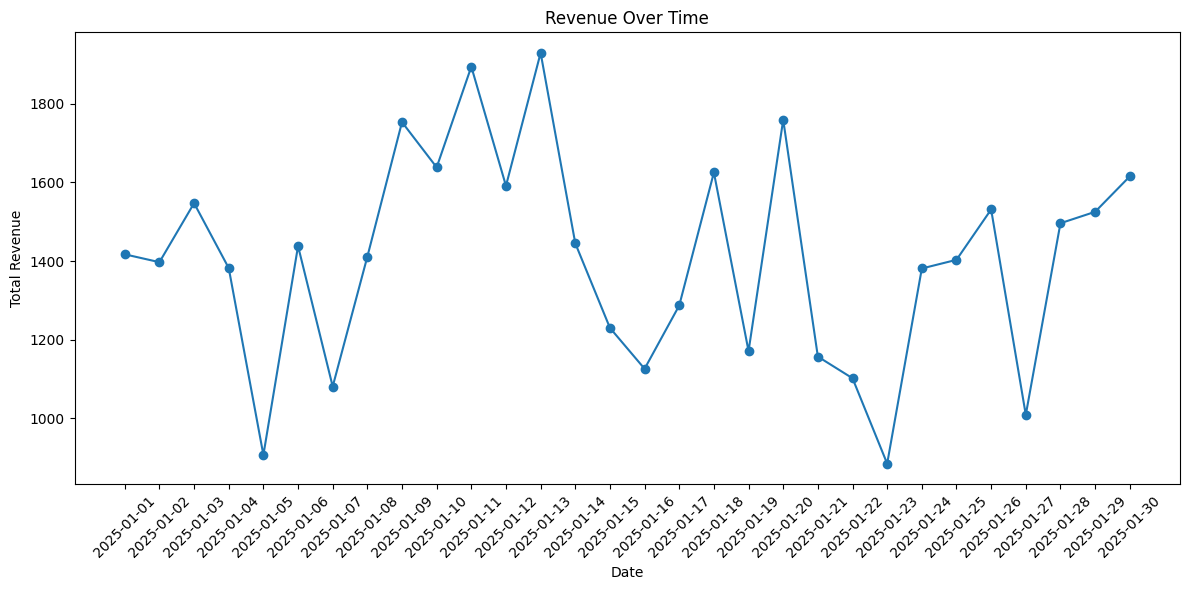

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(d_r.index, d_r.values, marker='o')
plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exercise 5: Compare Product Performance (Bar Chart)

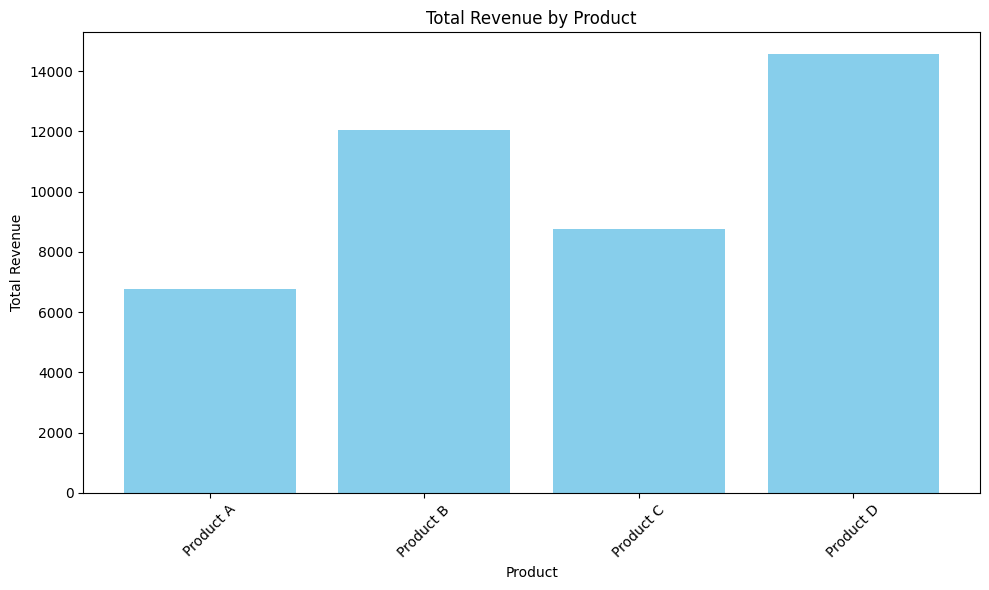

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(r_p.index, r_p.values, color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exercise 6: Average Units Sold per Product

In [23]:
u_p = df.groupby('product')['units_sold'].mean()
u_p

product
Product A    22.566667
Product B    26.733333
Product C    24.366667
Product D    24.266667
Name: units_sold, dtype: float64

### Exercise 7: Find Best Day (Highest Revenue)

In [25]:
bd = d_r.idxmax()
bd_r = d_r.max()
print(f"Best day: {bd}, Revenue: {bd_r}")

Best day: 2025-01-13, Revenue: 1929


### Exercise 8: Detect High Sales Days (Anomaly)

Days with revenue above average

In [27]:
anomaly = d_r[d_r > d_r.mean()]
print("High sales days (anomalies):")
anomaly

High sales days (anomalies):


date
2025-01-01    1417
2025-01-03    1547
2025-01-06    1438
2025-01-08    1411
2025-01-09    1753
2025-01-10    1638
2025-01-11    1894
2025-01-12    1591
2025-01-13    1929
2025-01-14    1445
2025-01-18    1625
2025-01-20    1759
2025-01-26    1531
2025-01-28    1496
2025-01-29    1525
2025-01-30    1615
Name: revenue, dtype: int64

### Exercise 9: Pivot Table (Business Dashboard Style)

In [ ]:
pivot = df.pivot_table(
    values='revenue', 
    index='date', 
    columns='product'
)
pivot

product,Product A,Product B,Product C,Product D
date,,,,
2025-01-01,140.0,405.0,432.0,440.0
2025-01-02,180.0,225.0,432.0,560.0
2025-01-03,140.0,495.0,312.0,600.0
2025-01-04,180.0,270.0,372.0,560.0
2025-01-05,110.0,225.0,372.0,200.0
2025-01-06,290.0,420.0,108.0,620.0
2025-01-07,190.0,555.0,156.0,180.0
2025-01-08,390.0,525.0,336.0,160.0
2025-01-09,190.0,495.0,348.0,720.0


### Exercise 10: Visualization – Multi-line Product Trend

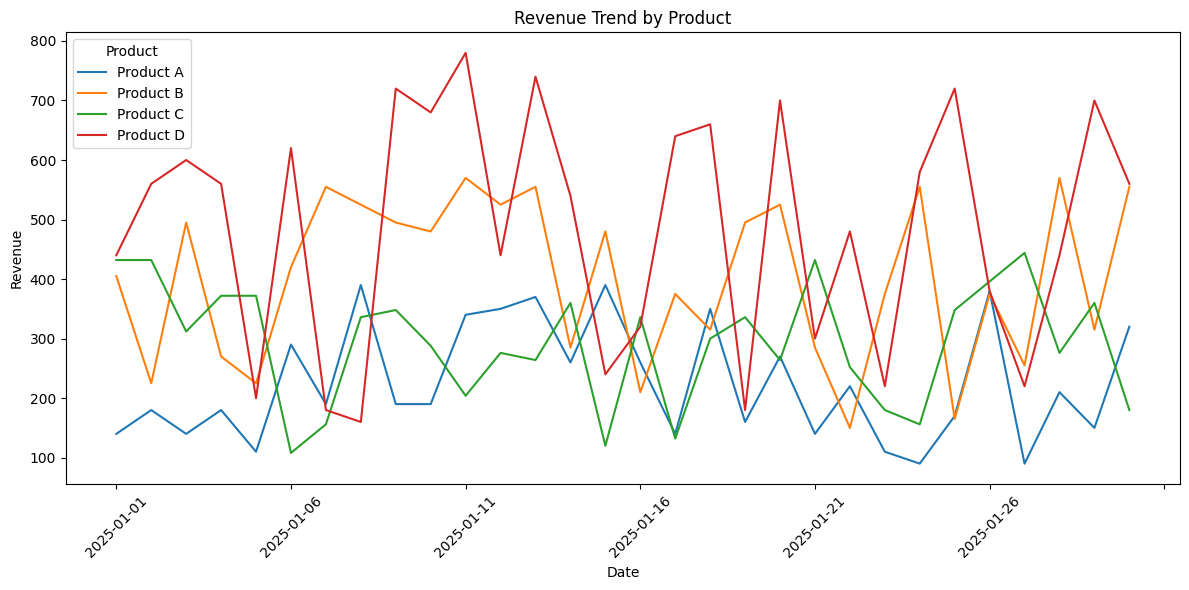

In [ ]:
pivot.plot(kind='line', figsize=(12, 6))
plt.title('Revenue Trend by Product')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Product')
plt.tight_layout()
plt.show()